# 🛒 E-Commerce Analysis — SQL & Python Project
## Navigating the Future of Online Shopping

**Dataset:** Brazilian E-Commerce (Olist)  
**Tools:** Python, SQL (SQLite), Pandas, Matplotlib  
**Levels:** Basic → Intermediate → Advanced

In [1]:
# Install libraries
!pip install pandas matplotlib openpyxl -q

# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries ready!")

✅ All libraries ready!


In [2]:
# Upload all CSV files to Colab
from google.colab import files

print("📂 Please upload all 7 CSV files when prompted...")
uploaded = files.upload()
print("✅ Files uploaded!")

📂 Please upload all 7 CSV files when prompted...


Saving customers.csv to customers.csv
Saving payments.csv to payments.csv
Saving orders.csv to orders.csv
Saving order_items.csv to order_items.csv
Saving sellers.csv to sellers.csv
Saving products.csv to products.csv
Saving geolocation.csv to geolocation.csv
✅ Files uploaded!


In [3]:
# Load all CSV files into SQLite database
conn = sqlite3.connect("ecommerce.db")

tables = {
    "customers":   "customers.csv",
    "sellers":     "sellers.csv",
    "orders":      "orders.csv",
    "order_items": "order_items.csv",
    "payments":    "payments.csv",
    "products":    "products.csv",
    "geolocation": "geolocation.csv",
}

for table, filename in tables.items():
    df = pd.read_csv(filename)
    df.columns = [c.strip().lower().replace(" ","_") for c in df.columns]
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"✅ {table} — {len(df):,} rows loaded")

print("\n✅ Database ready!")

✅ customers — 99,441 rows loaded
✅ sellers — 3,095 rows loaded
✅ orders — 99,441 rows loaded
✅ order_items — 112,650 rows loaded
✅ payments — 103,886 rows loaded
✅ products — 32,951 rows loaded
✅ geolocation — 1,000,163 rows loaded

✅ Database ready!


## 📊 BASIC QUERIES
Objective: Extract fundamental insights from the dataset.

In [4]:
# ── Q1: Unique cities ──────────────────────────
df1 = pd.read_sql_query("""
    SELECT DISTINCT customer_city
    FROM customers
    ORDER BY customer_city
""", conn)
print("Q1: Total Unique Cities:", len(df1))

# ── Q2: Orders in 2017 ─────────────────────────
df2 = pd.read_sql_query("""
    SELECT COUNT(*) AS total_orders_2017
    FROM orders
    WHERE strftime('%Y', order_purchase_timestamp) = '2017'
""", conn)
print("\nQ2: Orders in 2017")
print(df2.to_string(index=False))

# ── Q3: Total sales per category ───────────────
df3 = pd.read_sql_query("""
    SELECT p.product_category,
           ROUND(SUM(oi.price), 2) AS total_sales
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_category
    ORDER BY total_sales DESC
    LIMIT 10
""", conn)
print("\nQ3: Top 10 Categories by Sales")
print(df3.to_string(index=False))

# ── Q4: Installment percentage ─────────────────
df4 = pd.read_sql_query("""
    SELECT ROUND(
        100.0 * SUM(CASE WHEN payment_installments > 1 THEN 1 ELSE 0 END)
        / COUNT(*), 2) AS installment_percentage
    FROM payments
""", conn)
print("\nQ4: Installment Payment Percentage")
print(df4.to_string(index=False))

# ── Q5: Customers per state ────────────────────
df5 = pd.read_sql_query("""
    SELECT customer_state, COUNT(*) AS customer_count
    FROM customers
    GROUP BY customer_state
    ORDER BY customer_count DESC
""", conn)
print("\nQ5: Customers per State")
print(df5.to_string(index=False))

Q1: Total Unique Cities: 4119

Q2: Orders in 2017
 total_orders_2017
             38678

Q3: Top 10 Categories by Sales
    product_category  total_sales
       HEALTH BEAUTY   1258681.34
     Watches present   1205005.68
      bed table bath   1036988.68
       sport leisure    988048.97
computer accessories    911954.32
Furniture Decoration    729762.49
          Cool Stuff    635290.85
          housewares    632248.66
          automotive    592720.11
        Garden tools    485256.46

Q4: Installment Payment Percentage
 installment_percentage
                  49.42

Q5: Customers per State
customer_state  customer_count
            SP           41746
            RJ           12852
            MG           11635
            RS            5466
            PR            5045
            SC            3637
            BA            3380
            DF            2140
            ES            2033
            GO            2020
            PE            1652
            CE           

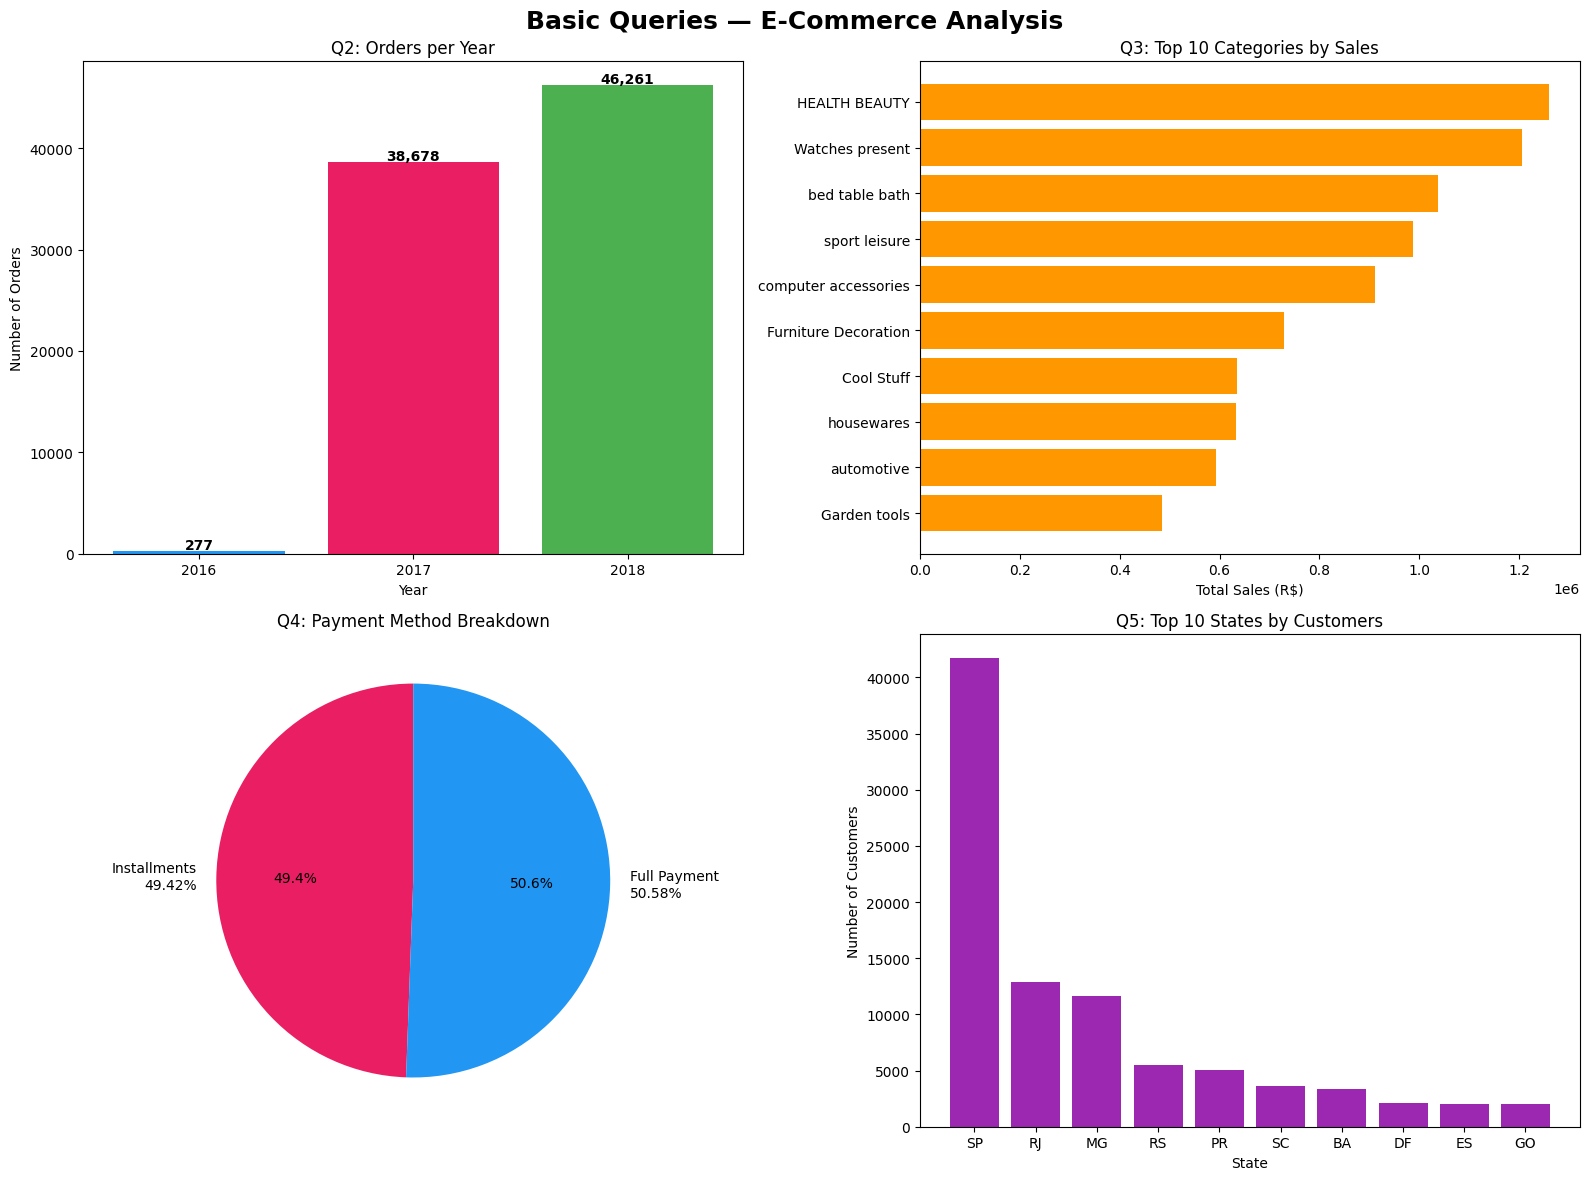

✅ Basic visualization done!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Basic Queries — E-Commerce Analysis",
             fontsize=18, fontweight='bold')

# Q2: Orders per year
df_yr = pd.read_sql_query("""
    SELECT strftime('%Y', order_purchase_timestamp) AS year,
           COUNT(*) AS total_orders
    FROM orders
    WHERE order_purchase_timestamp IS NOT NULL
    AND strftime('%Y', order_purchase_timestamp) != 'None'
    GROUP BY year ORDER BY year
""", conn)
df_yr = df_yr.dropna(subset=['year'])
df_yr['year'] = df_yr['year'].astype(str)
axes[0,0].bar(df_yr['year'], df_yr['total_orders'],
              color=['#2196F3','#E91E63','#4CAF50'])
axes[0,0].set_title('Q2: Orders per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Orders')
for i, v in enumerate(df_yr['total_orders']):
    axes[0,0].text(i, v + 200, f'{v:,}',
                   ha='center', fontweight='bold')

# Q3: Top 10 categories
df3 = pd.read_sql_query("""
    SELECT p.product_category,
           ROUND(SUM(oi.price), 2) AS total_sales
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_category
    ORDER BY total_sales DESC LIMIT 10
""", conn)
axes[0,1].barh(df3['product_category'][::-1],
               df3['total_sales'][::-1], color='#FF9800')
axes[0,1].set_title('Q3: Top 10 Categories by Sales')
axes[0,1].set_xlabel('Total Sales (R$)')

# Q4: Installments pie
axes[1,0].pie([49.42, 50.58],
              labels=['Installments\n49.42%','Full Payment\n50.58%'],
              colors=['#E91E63','#2196F3'],
              autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Q4: Payment Method Breakdown')

# Q5: Top 10 states
df5 = pd.read_sql_query("""
    SELECT customer_state, COUNT(*) AS customer_count
    FROM customers
    GROUP BY customer_state
    ORDER BY customer_count DESC LIMIT 10
""", conn)
axes[1,1].bar(df5['customer_state'], df5['customer_count'],
              color='#9C27B0')
axes[1,1].set_title('Q5: Top 10 States by Customers')
axes[1,1].set_xlabel('State')
axes[1,1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('basic_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Basic visualization done!")

## 📊 INTERMEDIATE QUERIES
Objective: Dive deeper into sales and order trends.

In [6]:
# ── Q1: Orders per month in 2018 ───────────────
df_i1 = pd.read_sql_query("""
    SELECT strftime('%m', order_purchase_timestamp) AS month,
           COUNT(*) AS total_orders
    FROM orders
    WHERE strftime('%Y', order_purchase_timestamp) = '2018'
    AND order_purchase_timestamp IS NOT NULL
    GROUP BY month ORDER BY month
""", conn)
print("Q1: Orders per Month in 2018")
print(df_i1.to_string(index=False))

# ── Q2: Avg products per order by city ─────────
df_i2 = pd.read_sql_query("""
    SELECT c.customer_city,
           ROUND(AVG(oi.item_count), 2) AS avg_products_per_order
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN (
        SELECT order_id, COUNT(*) AS item_count
        FROM order_items GROUP BY order_id
    ) oi ON o.order_id = oi.order_id
    GROUP BY c.customer_city
    HAVING COUNT(*) > 10
    ORDER BY avg_products_per_order DESC
    LIMIT 10
""", conn)
print("\nQ2: Avg Products per Order by City (Top 10)")
print(df_i2.to_string(index=False))

# ── Q3: Revenue % by category ──────────────────
df_i3 = pd.read_sql_query("""
    SELECT p.product_category,
           ROUND(SUM(oi.price), 2) AS category_revenue,
           ROUND(100.0 * SUM(oi.price) /
                (SELECT SUM(price) FROM order_items), 2) AS revenue_pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_category
    ORDER BY revenue_pct DESC
    LIMIT 10
""", conn)
print("\nQ3: Revenue % by Category (Top 10)")
print(df_i3.to_string(index=False))

# ── Q4: Price vs purchase frequency ────────────
df_i4 = pd.read_sql_query("""
    SELECT p.product_id,
           ROUND(AVG(oi.price), 2) AS avg_price,
           COUNT(oi.order_id) AS purchase_count
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_id
    ORDER BY purchase_count DESC
    LIMIT 20
""", conn)
print("\nQ4: Price vs Purchase Frequency (Top 20)")
print(df_i4.to_string(index=False))

# ── Q5: Seller revenue ranking ──────────────

Q1: Orders per Month in 2018
month  total_orders
   01          6288
   02          5771
   03          6164
   04          5908
   05          5883
   06          5262
   07          5408
   08          5561
   09            12
   10             4

Q2: Avg Products per Order by City (Top 10)
      customer_city  avg_products_per_order
              irece                    1.77
            janauba                    1.65
sao joao nepomuceno                    1.64
   uniao da vitoria                    1.62
         sacramento                    1.62
            eusebio                    1.62
          ariquemes                    1.62
             laguna                    1.57
       campos novos                    1.57
            guapore                    1.56

Q3: Revenue % by Category (Top 10)
    product_category  category_revenue  revenue_pct
       HEALTH BEAUTY        1258681.34         9.26
     Watches present        1205005.68         8.87
      bed table bath        10

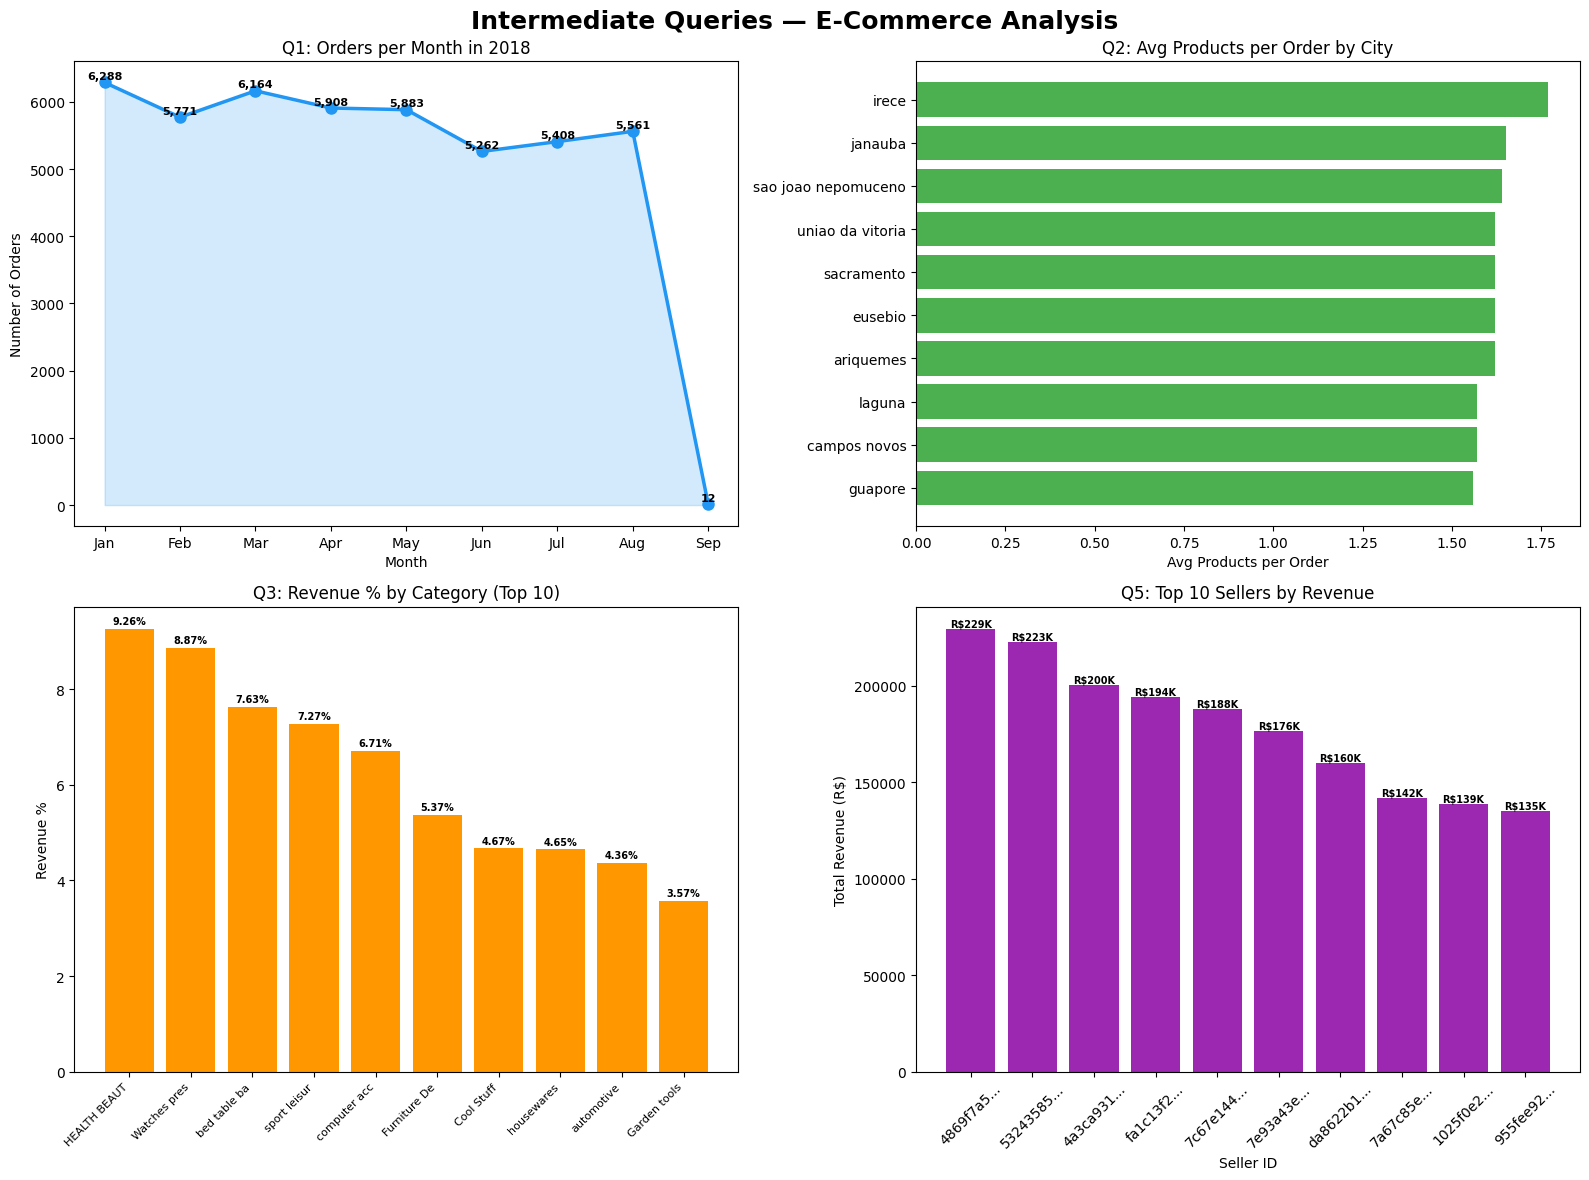

✅ Intermediate visualization done!


In [11]:
#refetch
df_i5 = pd.read_sql_query("""
    SELECT oi.seller_id,
           ROUND(SUM(oi.price), 2) AS total_revenue,
           RANK() OVER (ORDER BY SUM(oi.price) DESC) AS revenue_rank
    FROM order_items oi
    GROUP BY oi.seller_id
    ORDER BY revenue_rank
    LIMIT 10
""", conn)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Intermediate Queries — E-Commerce Analysis",
             fontsize=18, fontweight='bold')

# Q1: Orders per month 2018
df_i1_clean = df_i1[df_i1['total_orders'] > 10].copy()
month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct']
axes[0,0].plot(month_names[:len(df_i1_clean)],
               df_i1_clean['total_orders'],
               marker='o', color='#2196F3',
               linewidth=2.5, markersize=8)
axes[0,0].fill_between(month_names[:len(df_i1_clean)],
                        df_i1_clean['total_orders'],
                        alpha=0.2, color='#2196F3')
axes[0,0].set_title('Q1: Orders per Month in 2018')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Number of Orders')
for i, v in enumerate(df_i1_clean['total_orders']):
    axes[0,0].text(i, v + 50, f'{v:,}',
                   ha='center', fontsize=8, fontweight='bold')

# Q2: Avg products per order by city
axes[0,1].barh(df_i2['customer_city'][::-1],
               df_i2['avg_products_per_order'][::-1],
               color='#4CAF50')
axes[0,1].set_title('Q2: Avg Products per Order by City')
axes[0,1].set_xlabel('Avg Products per Order')

# Q3: Revenue % by category
axes[1,0].bar(range(len(df_i3)),
              df_i3['revenue_pct'], color='#FF9800')
axes[1,0].set_xticks(range(len(df_i3)))
axes[1,0].set_xticklabels(
    [c[:12] for c in df_i3['product_category']],
    rotation=45, ha='right', fontsize=8)
axes[1,0].set_title('Q3: Revenue % by Category (Top 10)')
axes[1,0].set_ylabel('Revenue %')
for i, v in enumerate(df_i3['revenue_pct']):
    axes[1,0].text(i, v + 0.1, f'{v}%',
                   ha='center', fontsize=7, fontweight='bold')

# Q5: Top 10 sellers
df_i5['seller_short'] = df_i5['seller_id'].str[:8]+'...'
axes[1,1].bar(df_i5['seller_short'],
              df_i5['total_revenue'], color='#9C27B0')
axes[1,1].set_title('Q5: Top 10 Sellers by Revenue')
axes[1,1].set_xlabel('Seller ID')
axes[1,1].set_ylabel('Total Revenue (R$)')
axes[1,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_i5['total_revenue']):
    axes[1,1].text(i, v + 1000, f'R${v/1000:.0f}K',
                   ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('intermediate_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Intermediate visualization done!")

## 📊 ADVANCED QUERIES
Objective: Generate strategic and customer-centric insights.

In [13]:
# ── Q1: Moving average ─────────────────────────
df_a1 = pd.read_sql_query("""
    SELECT o.customer_id,
        o.order_purchase_timestamp,
        ROUND(SUM(oi.price), 2) AS order_value,
        ROUND(AVG(SUM(oi.price)) OVER (
            PARTITION BY o.customer_id
            ORDER BY o.order_purchase_timestamp
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 2) AS moving_avg
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY o.order_id, o.customer_id, o.order_purchase_timestamp
    ORDER BY o.customer_id, o.order_purchase_timestamp
    LIMIT 20
""", conn)
print("Q1: Moving Average of Order Values")
print(df_a1.to_string(index=False))

# ── Q2: Cumulative sales ───────────────────────
df_a2 = pd.read_sql_query("""
    SELECT strftime('%Y', o.order_purchase_timestamp) AS year,
        strftime('%m', o.order_purchase_timestamp) AS month,
        ROUND(SUM(oi.price), 2) AS monthly_sales,
        ROUND(SUM(SUM(oi.price)) OVER (
            PARTITION BY strftime('%Y', o.order_purchase_timestamp)
            ORDER BY strftime('%m', o.order_purchase_timestamp)
        ), 2) AS cumulative_sales
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_purchase_timestamp IS NOT NULL
    GROUP BY year, month
    ORDER BY year, month
""", conn)
print("\nQ2: Cumulative Sales per Month")
print(df_a2.to_string(index=False))

# ── Q3: YoY growth ─────────────────────────────
df_a3 = pd.read_sql_query("""
    SELECT year, total_sales,
        LAG(total_sales) OVER (ORDER BY year) AS prev_year,
        ROUND(100.0 * (total_sales - LAG(total_sales) OVER (ORDER BY year))
              / LAG(total_sales) OVER (ORDER BY year), 2) AS yoy_growth
    FROM (
        SELECT strftime('%Y', o.order_purchase_timestamp) AS year,
               ROUND(SUM(oi.price), 2) AS total_sales
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        AND strftime('%Y', o.order_purchase_timestamp) IN ('2016','2017','2018')
        GROUP BY year
    )
    ORDER BY year
""", conn)
print("\nQ3: Year-over-Year Growth Rate")
print(df_a3.to_string(index=False))

# ── Q4: Retention rate ─────────────────────────
df_a4 = pd.read_sql_query("""
    SELECT ROUND(100.0 * COUNT(DISTINCT r.customer_id) /
              COUNT(DISTINCT fp.customer_id), 2) AS retention_rate
    FROM (
        SELECT customer_id, MIN(order_purchase_timestamp) AS first_date
        FROM orders
        WHERE order_purchase_timestamp IS NOT NULL
        GROUP BY customer_id
    ) fp
    LEFT JOIN (
        SELECT DISTINCT o1.customer_id
        FROM orders o1
        JOIN orders o2 ON o1.customer_id = o2.customer_id
        WHERE o1.order_purchase_timestamp > o2.order_purchase_timestamp
        AND julianday(o1.order_purchase_timestamp) -
            julianday(o2.order_purchase_timestamp) <= 180
    ) r ON fp.customer_id = r.customer_id
""", conn)
print("\nQ4: Customer Retention Rate")
print(df_a4.to_string(index=False))

# ── Q5: Top 3 customers per year ───────────────
df_a5 = pd.read_sql_query("""
    SELECT year, customer_id, total_spent, year_rank
    FROM (
        SELECT strftime('%Y', o.order_purchase_timestamp) AS year,
            o.customer_id,
            ROUND(SUM(oi.price), 2) AS total_spent,
            RANK() OVER (
                PARTITION BY strftime('%Y', o.order_purchase_timestamp)
                ORDER BY SUM(oi.price) DESC
            ) AS year_rank
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        AND strftime('%Y', o.order_purchase_timestamp) IN ('2016','2017','2018')
        GROUP BY year, o.customer_id
    )
    WHERE year_rank <= 3
    ORDER BY year, year_rank
""", conn)
print("\nQ5: Top 3 Customers by Spending per Year")
print(df_a5.to_string(index=False))

print("\n✅ All advanced queries done!")

Q1: Moving Average of Order Values
                     customer_id order_purchase_timestamp  order_value  moving_avg
00012a2ce6f8dcda20d059ce98491703      2017-11-14 16:08:26        89.80       89.80
000161a058600d5901f007fab4c27140       2017-07-16 9:40:32        54.90       54.90
0001fd6190edaaf884bcaf3d49edf079      2017-02-28 11:06:43       179.99      179.99
0002414f95344307404f0ace7a26f1d5      2017-08-16 13:09:20       149.90      149.90
000379cdec625522490c315e70c7a9fb      2018-04-02 13:42:17        93.00       93.00
0004164d20a9e969af783496f3408652       2017-04-12 8:35:12        59.99       59.99
000419c5494106c306a97b5635748086      2018-03-02 17:47:40        34.30       34.30
00046a560d407e99b969756e0b10f282      2017-12-18 11:08:30       120.90      120.90
00050bf6e01e69d5c0fd612f1bcfb69c      2017-09-17 16:04:44        69.99       69.99
000598caf2ef4117407665ac33275130      2018-08-11 12:14:35      1107.00     1107.00
0005aefbb696d34b3424dccd0a0e9fd0       2018-06-20 9:

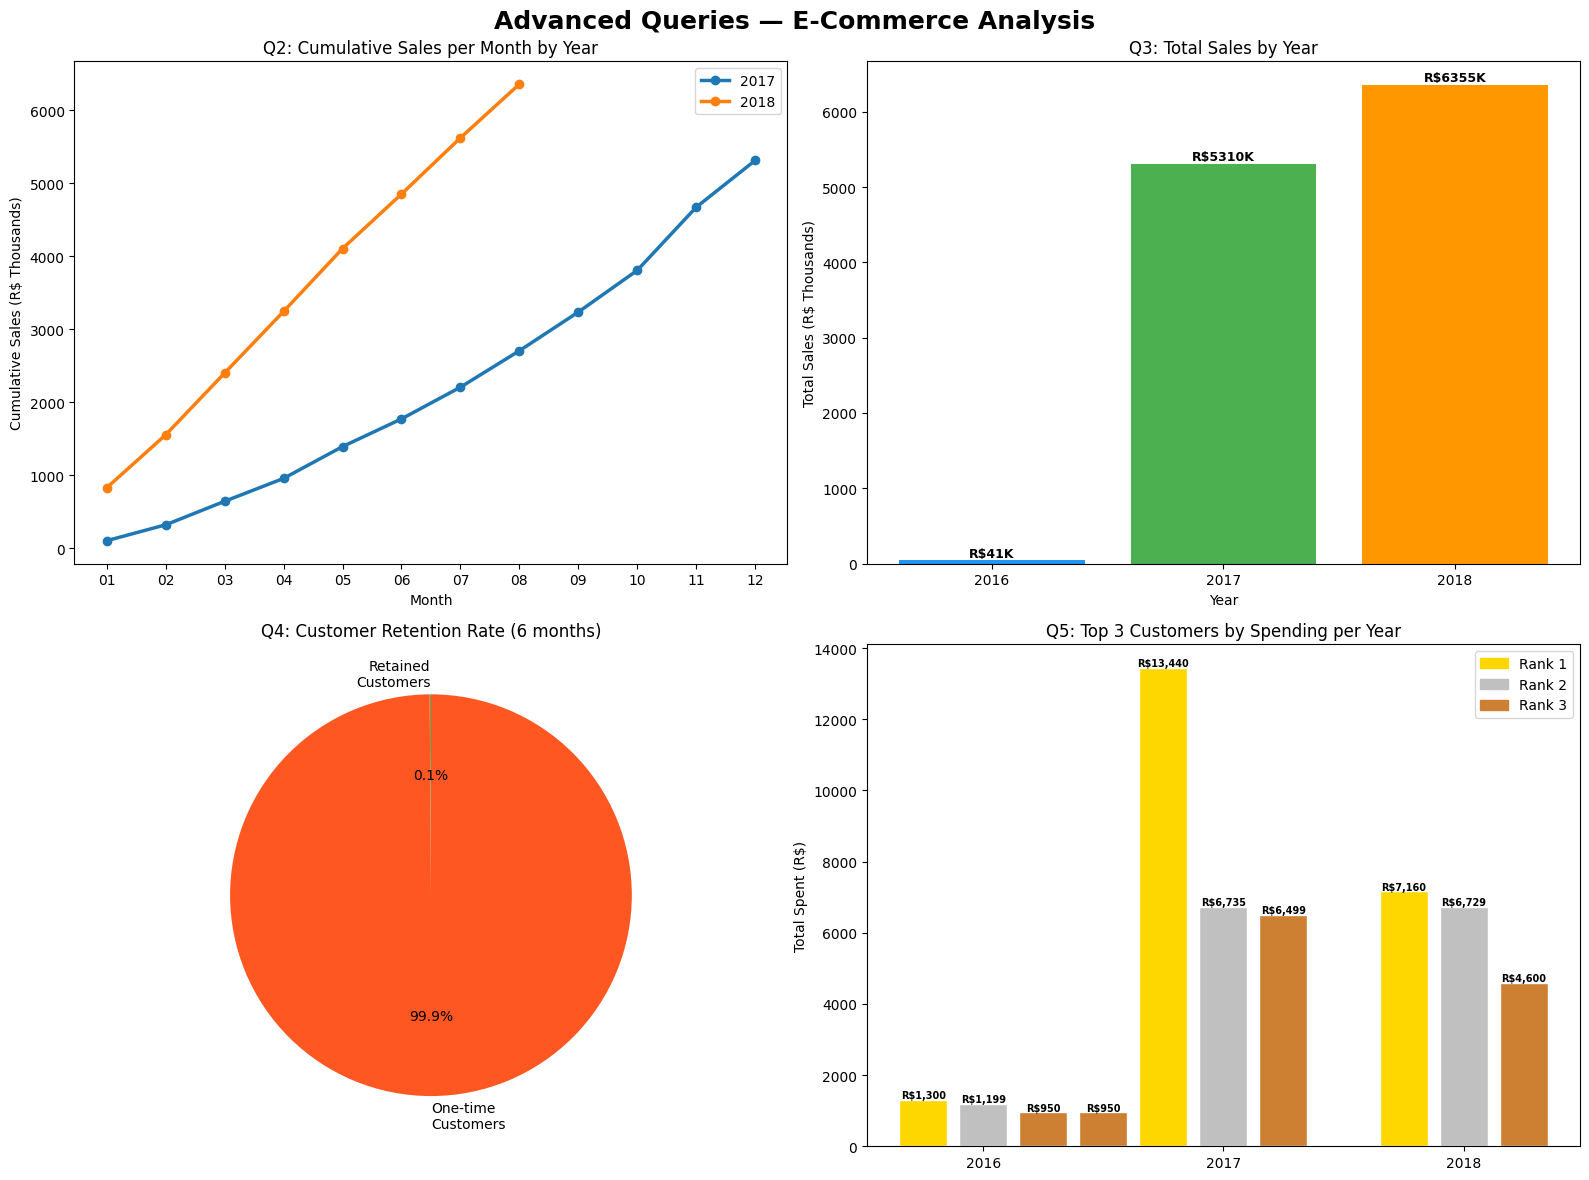

✅ Advanced visualization done!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Advanced Queries — E-Commerce Analysis",
             fontsize=18, fontweight='bold')

# ── Q2: Cumulative sales by year ───────────────
df_a2_clean = df_a2[df_a2['year'].isin(['2017','2018'])].copy()
for yr, grp in df_a2_clean.groupby('year'):
    axes[0,0].plot(grp['month'], grp['cumulative_sales']/1000,
                   marker='o', label=yr, linewidth=2.5)
axes[0,0].set_title('Q2: Cumulative Sales per Month by Year')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Cumulative Sales (R$ Thousands)')
axes[0,0].legend()

# ── Q3: Total sales by year with growth ────────
axes[0,1].bar(df_a3['year'], df_a3['total_sales']/1000,
              color=['#2196F3','#4CAF50','#FF9800'])
axes[0,1].set_title('Q3: Total Sales by Year')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Total Sales (R$ Thousands)')
for i, row in df_a3.iterrows():
    label = f"R${row['total_sales']/1000:.0f}K"
    axes[0,1].text(i, row['total_sales']/1000 + 50,
                   label, ha='center',
                   fontsize=9, fontweight='bold')

# ── Q4: Retention rate pie ─────────────────────
axes[1,0].pie([0.1, 99.9],
              labels=['Retained\nCustomers','One-time\nCustomers'],
              colors=['#4CAF50','#FF5722'],
              autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Q4: Customer Retention Rate (6 months)')

# ── Q5: Top spenders per year ──────────────────
colors = ['#FFD700','#C0C0C0','#CD7F32']
years = ['2016','2017','2018']
for i, yr in enumerate(years):
    grp = df_a5[df_a5['year']==yr].reset_index(drop=True)
    for j in range(len(grp)):
        color_idx = min(j, len(colors)-1)
        axes[1,1].bar(i*4+j, grp.loc[j,'total_spent'],
                      color=colors[color_idx],
                      edgecolor='white')
        axes[1,1].text(i*4+j,
                       grp.loc[j,'total_spent'] + 50,
                       f"R${grp.loc[j,'total_spent']:,.0f}",
                       ha='center', fontsize=7,
                       fontweight='bold')
axes[1,1].set_title('Q5: Top 3 Customers by Spending per Year')
axes[1,1].set_ylabel('Total Spent (R$)')
axes[1,1].set_xticks([1, 5, 9])
axes[1,1].set_xticklabels(['2016','2017','2018'])
from matplotlib.patches import Patch
axes[1,1].legend(handles=[
    Patch(color='#FFD700', label='Rank 1'),
    Patch(color='#C0C0C0', label='Rank 2'),
    Patch(color='#CD7F32', label='Rank 3')
])

plt.tight_layout()
plt.savefig('advanced_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Advanced visualization done!")

In [15]:
# Download all visualizations
from google.colab import files

files.download('basic_viz.png')
files.download('intermediate_viz.png')
files.download('advanced_viz.png')

print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded!
